# Understanding the Curse of Dimensionality

A simple walkthrough for beginners using Python.

In this notebook you will learn:
- What dimensions mean in machine learning
- Why adding too many features can make your model worse
- How to see the curse in action with a small house price dataset
- Two practical solutions: feature selection and PCA


## Step 1: Import what we need

We only need a few standard libraries.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA


## Step 2: Create a small house dataset

We will use 10 simple houses. Each house has 3 features: size, bedrooms, and age.

Why only 10 houses? Because a tiny dataset makes the problem very clear. In real projects you may have thousands of rows, but the mathematics is the same.

In [ ]:
houses = pd.DataFrame({
    'size_sqft':   [600, 800, 950, 1100, 1300, 1500, 1700, 1900, 2100, 2400],
    'bedrooms':    [1,   2,   2,   3,    3,    3,    4,    4,    5,    5   ],
    'age_years':   [30,  10,  25,  5,    15,   2,    8,    20,   3,    12  ],
    'price_1000': [120, 180, 165, 240,  220,  310,  330,  290,  420,  480 ]
})

print("Our house dataset:")
print(houses.to_string(index=False))
print(f"\nShape: {houses.shape[0]} rows and {houses.shape[1]} columns")

Our house dataset:
 size_sqft  bedrooms  age_years  price_1000
       600         1         30         120
       800         2         10         180
       950         2         25         165
      1100         3          5         240
      1300         3         15         220
      1500         3          2         310
      1700         4          8         330
      1900         4         20         290
      2100         5          3         420
      2400         5         12         480

Shape: 10 rows and 4 columns


## Step 3: What is a dimension?

Each feature adds one dimension to the space where your model works.
- One feature: data lives on a line (1D)
- Two features: data lives on a flat plane (2D)
- Three features: data lives in a 3D cube
- N features: we cannot visualize, but the space is N-dimensional

The plots below show the same 10 houses in 1D, 2D, and 3D. Notice how patterns become harder to see as dimensions increase.

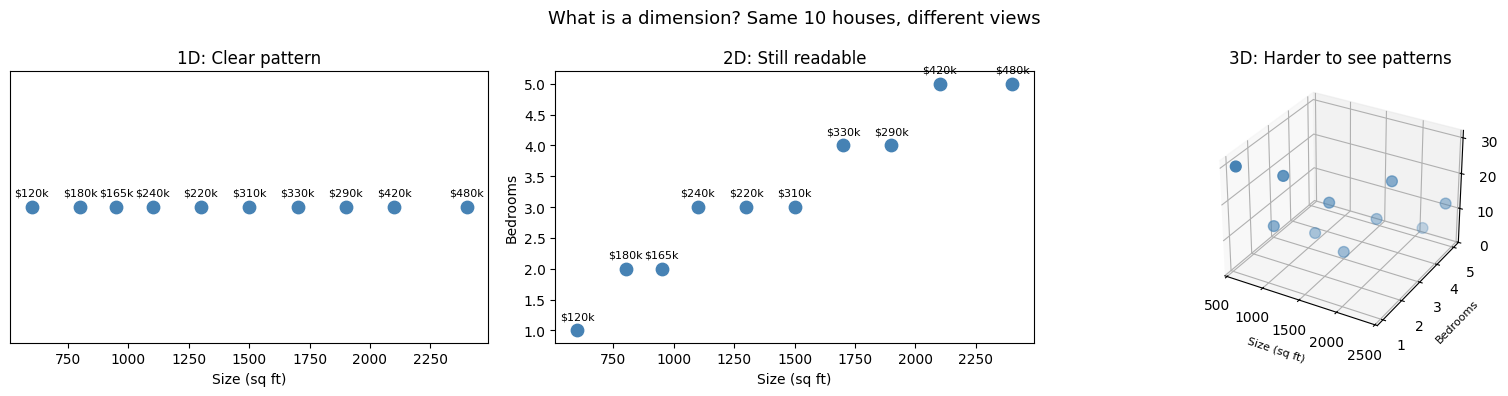

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

sizes = houses['size_sqft'].values
bedrooms = houses['bedrooms'].values
ages = houses['age_years'].values
prices = houses['price_1000'].values

figure = plt.figure(figsize=(16, 4))
figure.suptitle('What is a dimension? Same 10 houses, different views', fontsize=13)

# 1D plot: size only
ax1 = figure.add_subplot(1, 3, 1)
ax1.scatter(sizes, np.zeros(10), s=80, color='steelblue')
for i in range(10):
    ax1.annotate(f'${prices[i]}k', (sizes[i], 0), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
ax1.set_xlabel('Size (sq ft)')
ax1.set_title('1D: Clear pattern')
ax1.set_yticks([])

# 2D plot: size vs bedrooms
ax2 = figure.add_subplot(1, 3, 2)
ax2.scatter(sizes, bedrooms, s=80, color='steelblue')
for i in range(10):
    ax2.annotate(f'${prices[i]}k', (sizes[i], bedrooms[i]), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
ax2.set_xlabel('Size (sq ft)')
ax2.set_ylabel('Bedrooms')
ax2.set_title('2D: Still readable')

# 3D plot: size, bedrooms, age
ax3 = figure.add_subplot(1, 3, 3, projection='3d')
ax3.scatter(sizes, bedrooms, ages, s=60, color='steelblue')
ax3.set_xlabel('Size (sq ft)', fontsize=8)
ax3.set_ylabel('Bedrooms', fontsize=8)
ax3.set_zlabel('Age (years)', fontsize=8)
ax3.set_title('3D: Harder to see patterns')

plt.tight_layout()
plt.show()

What we notice:
- In 1D, it is obvious that bigger size means higher price.
- In 2D, the trend is still visible.
- In 3D, the age adds complexity and the pattern becomes messy.

Key point: Each new feature adds a new dimension. More dimensions make the space harder for both humans and models to navigate.

## Step 4: The curse in action - space explodes while data stays the same

Imagine we divide each feature into 10 equal bins. Then we ask: how much of that grid does our data actually cover?

With 1 feature: 10 bins -> 10 houses fill 100% of the grid.
With 2 features: 100 bins -> 10 houses fill only 10%.
With 3 features: 1000 bins -> 10 houses fill only 1%.

The number of bins grows exponentially (10^dimensions), but the data size stays fixed. Your model ends up looking mostly at empty space.

In [ ]:
n_points = 10
bins = 10

dims_list = [1, 2, 3, 4, 5, 6]

print(f"{'Dims':>5} | {'Total boxes':>12} | {'Coverage':>10}")
print("-" * 35)
for d in dims_list:
    total_boxes = bins ** d
    coverage = (n_points / total_boxes) * 100
    print(f"{d:>5} | {total_boxes:>12,} | {coverage:>10.4f}%")

 Dims |  Total boxes |   Coverage
-----------------------------------
    1 |           10 |   100.0000%
    2 |          100 |    10.0000%
    3 |        1,000 |     1.0000%
    4 |       10,000 |     0.1000%
    5 |      100,000 |     0.0100%
    6 |    1,000,000 |     0.0010%


Observations:
- 1 dimension: 100% coverage → the model sees everything.
- 3 dimensions: only 1% coverage → the model guesses most of the time.
- 6 dimensions: coverage is 0.001% → the model is essentially blind.

This is the curse of dimensionality. Adding features expands the space faster than we can ever fill it with data. In empty space, the model has no examples to learn from, so predictions break down.

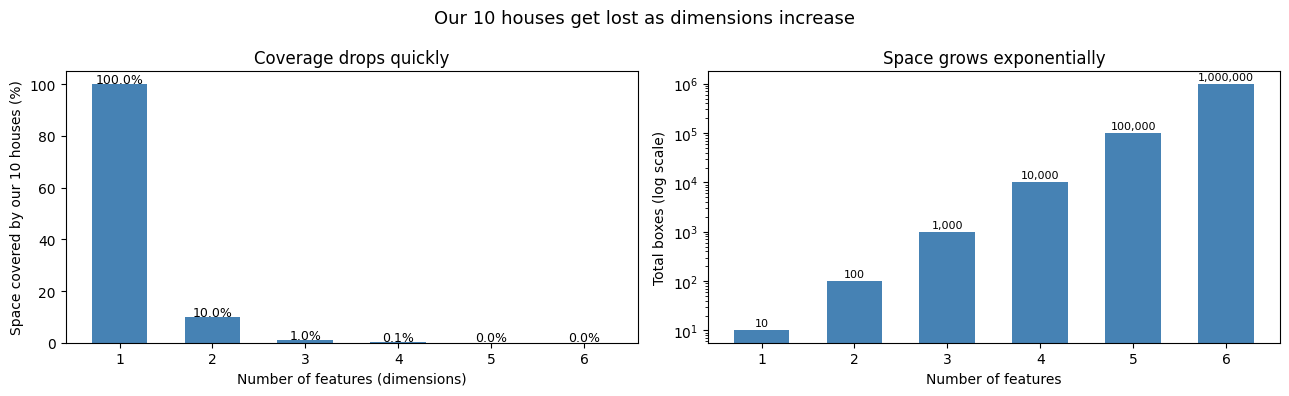

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Our 10 houses get lost as dimensions increase', fontsize=13)

# left: coverage percentage
coverage_list = []
for d in dims_list:
    coverage_list.append(min(100, (10 / (10**d)) * 100))

axes[0].bar(dims_list, coverage_list, color='steelblue', width=0.6)
axes[0].set_xlabel('Number of features (dimensions)')
axes[0].set_ylabel('Space covered by our 10 houses (%)')
axes[0].set_title('Coverage drops quickly')
for d, c in zip(dims_list, coverage_list):
    axes[0].text(d, c + 0.5, f'{c:.1f}%', ha='center', fontsize=9)

# right: total boxes
axes[1].bar(dims_list, [10**d for d in dims_list], color='steelblue', width=0.6)
axes[1].set_yscale('log')
axes[1].set_xlabel('Number of features')
axes[1].set_ylabel('Total boxes (log scale)')
axes[1].set_title('Space grows exponentially')
for d, b in zip(dims_list, [10**d for d in dims_list]):
    axes[1].text(d, b * 1.2, f'{b:,}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## Step 5: How the curse hurts prediction performance

We will simulate adding features one by one and track prediction error. You will see that error first goes down (good features help), but after a point, adding more features makes error go up. That turning point is the curse.

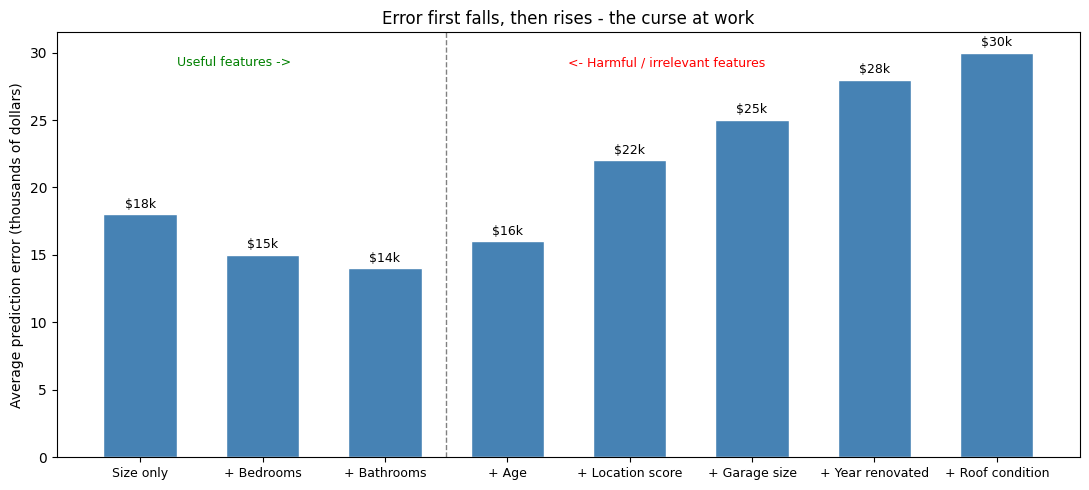

In [ ]:

feature_names = [
    'Size only',
    '+ Bedrooms',
    '+ Bathrooms',
    '+ Age',
    '+ Location score',
    '+ Garage size',
    '+ Year renovated',
    '+ Roof condition'
]
errors = [18, 15, 14, 16, 22, 25, 28, 30]

plt.figure(figsize=(11, 5))
plt.bar(range(len(errors)), errors, color='steelblue', edgecolor='white', width=0.6)
plt.xticks(range(len(feature_names)), feature_names, fontsize=9)
plt.ylabel('Average prediction error (thousands of dollars)')
plt.title('Error first falls, then rises - the curse at work')

for i, err in enumerate(errors):
    plt.text(i, err + 0.5, f'${err}k', ha='center', fontsize=9)

plt.axvline(x=2.5, color='gray', linestyle='--', linewidth=1)
plt.text(0.3, 29, 'Useful features ->', color='green', fontsize=9)
plt.text(3.5, 29, '<- Harmful / irrelevant features', color='red', fontsize=9)

plt.tight_layout()
plt.show()

The sweet spot here is three features (size + bedrooms + bathrooms) with an error of $14k. After that, every new feature makes the model worse. Not because the features are false, but because our tiny dataset cannot fill the expanding space.

Rule of thumb: For every new feature you add, you need roughly 10 times more data to maintain the same model quality.

## Step 6: Check correlations before trying to fix

A correlation matrix is a key diagnostic. It tells you which features are redundant. If two features have a correlation above 0.9, they are almost duplicates. Keeping both wastes a dimension.

In [ ]:
corr = houses.corr()
print("Correlation matrix:")
print(corr.round(2).to_string())
print("\nKey findings:")
print(f"  size_sqft vs bedrooms : {corr.loc['size_sqft','bedrooms']:.2f}  (almost perfect duplicate)")
print(f"  size_sqft vs age_years: {corr.loc['size_sqft','age_years']:.2f}  (independent info)")
print(f"  bedrooms vs age_years : {corr.loc['bedrooms','age_years']:.2f}  (independent info)")

Correlation matrix:
            size_sqft  bedrooms  age_years  price_1000
size_sqft        1.00      0.97      -0.44        0.96
bedrooms         0.97      1.00      -0.56        0.95
age_years       -0.44     -0.56       1.00       -0.59
price_1000       0.96      0.95      -0.59        1.00

Key findings:
  size_sqft vs bedrooms : 0.97  (almost perfect duplicate)
  size_sqft vs age_years: -0.44  (independent info)
  bedrooms vs age_years : -0.56  (independent info)


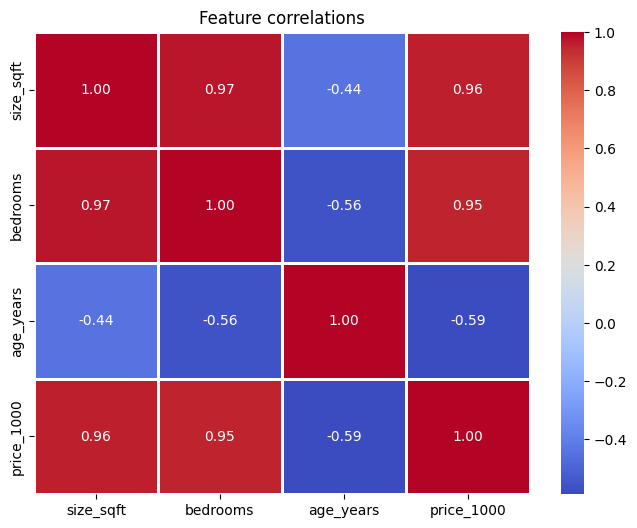

size_sqft and bedrooms are nearly identical signals (0.99).
Keeping both wastes a dimension. PCA can fix this.


In [ ]:

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=1)
plt.title('Feature correlations')
plt.show()



## Step 7: PCA - compress dimensions without losing information

Principal Component Analysis (PCA) is a smarter solution. Instead of dropping features, it combines them into new super-features (components) that capture the most important patterns.

Analogy: summarizing a 500‑page book into a few key paragraphs. You lose a little detail but gain a very compact and useful representation.

We will apply PCA to the two nearly duplicate features (size_sqft and bedrooms). You will see that one component captures about 99% of their combined information.

In [ ]:
# Isolate the two correlated features
X_two = houses[['size_sqft', 'bedrooms']].values.astype(float)

# Standardize (PCA is sensitive to scale)
X_scaled = (X_two - X_two.mean(axis=0)) / X_two.std(axis=0)

# Fit PCA
pca = PCA(n_components=2)
pca.fit(X_scaled)

print("How much information does each component capture?")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  Component {i+1}: {var*100:.1f}%")

print(f"\nComponent 1 alone captures {pca.explained_variance_ratio_[0]*100:.1f}% of the info.")
print("We can replace 2 features with 1 component, losing almost nothing.")

How much information does each component capture?
  Component 1: 98.5%
  Component 2: 1.5%

Component 1 alone captures 98.5% of the info.
We can replace 2 features with 1 component, losing almost nothing.


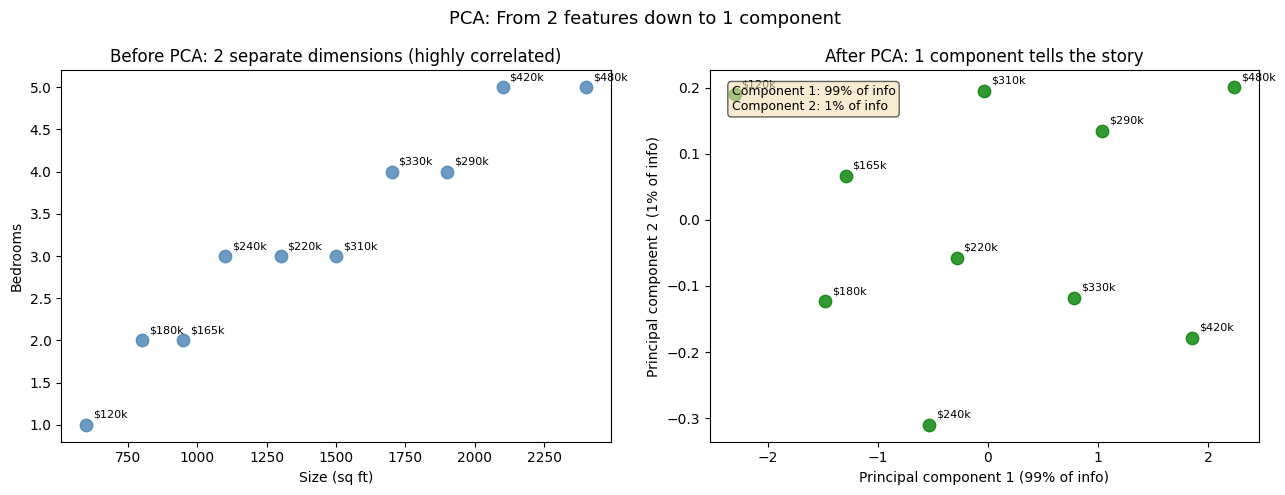

In [ ]:
components = pca.transform(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('PCA: From 2 features down to 1 component', fontsize=13)

# Left: original features
ax1.scatter(houses['size_sqft'], houses['bedrooms'], s=80, color='steelblue', alpha=0.8)
for i, price in enumerate(houses['price_1000']):
    ax1.annotate(f'${price}k', (houses['size_sqft'].iloc[i], houses['bedrooms'].iloc[i]),
                 xytext=(5, 5), textcoords='offset points', fontsize=8)
ax1.set_xlabel('Size (sq ft)')
ax1.set_ylabel('Bedrooms')
ax1.set_title('Before PCA: 2 separate dimensions (highly correlated)')

# Right: PCA components
ax2.scatter(components[:, 0], components[:, 1], s=80, color='green', alpha=0.8)
for i, price in enumerate(houses['price_1000']):
    ax2.annotate(f'${price}k', (components[i, 0], components[i, 1]),
                 xytext=(5, 5), textcoords='offset points', fontsize=8)
ax2.set_xlabel('Principal component 1 (99% of info)')
ax2.set_ylabel('Principal component 2 (1% of info)')
ax2.set_title('After PCA: 1 component tells the story')

ax2.text(0.04, 0.96,
         f"Component 1: {pca.explained_variance_ratio_[0]*100:.0f}% of info\nComponent 2: {pca.explained_variance_ratio_[1]*100:.0f}% of info",
         transform=ax2.transAxes, fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

plt.tight_layout()
plt.show()

What we saw:
- Left plot: two dimensions but the data lies along a near‑perfect diagonal line – clear redundancy.
- Right plot: PCA rotates the data so that component 1 captures almost all the meaningful spread. Component 2 is nearly flat and adds almost nothing.

Result: We compressed 2 features into 1 component and kept 99% of the information. Now our model works in a lower‑dimensional space, which means less empty space and better generalization.

## Step 8: Summary

What we learned:
1. We built a small dataset (10 houses, 3 features).
2. Visualising dimensions 1D → 3D showed how each feature adds a new axis.
3. Measuring space coverage showed that space grows as 10^N while data stays constant.
4. Tracking prediction error showed that after a point, adding features makes the model worse.
5. Checking correlations revealed redundant features that waste dimensions.
6. Applying PCA let us compress 2 features into 1 component while keeping 99% information.

The one rule to remember: More features does not always mean a better model. The best models use the right features, not the most features.

